## Import Model Ready Data Set

In [3]:
import numpy as np
import pandas as pd

In [4]:
model_df = pd.read_csv('team_stats_model_ready.csv')
model_df

,season,team,off_pass_TD%,off_pass_Int%,def_pass_Y/A,off_rush_TD%,def_rush_Y/A,def_pass_Int%,def_adv_Prss%,made_playoffs
0,2018,New England Patriots,5.1,1.9,6.9,0.037657,4.9,3.0,0.232,1
1,2018,Miami Dolphins,5.7,2.9,8.2,0.018868,4.8,4.1,0.258,0
2,2018,Buffalo Bills,2.6,4.6,6.3,0.032051,4.2,3.3,0.280,0
3,2018,New York Jets,3.4,3.6,7.5,0.026829,4.6,2.2,0.241,0
4,2018,Baltimore Ravens,3.2,1.6,6.3,0.034735,3.7,2.1,0.289,1
...,...,...,...,...,...,...,...,...,...,...
251,2025,New Orleans Saints,3.2,2.0,6.8,0.020690,4.0,2.0,0.247,0
252,2025,Seattle Seahawks,5.2,3.1,6.0,0.037475,3.7,3.0,0.261,1
253,2025,Los Angeles Rams,7.7,1.3,6.8,0.036559,4.3,2.7,0.263,1
254,2025,San Francisco 49ers,5.7,2.8,7.0,0.031185,4.3,1.0,0.167,1


Stating the final features from the reduce features work book

In [5]:
final_features = [
    # Passing (efficiency + mistakes)
    "off_pass_TD%",
    "off_pass_Int%",
    
    # Defensive passing disruption
    "def_pass_Y/A",
    
    # Rushing
    "off_rush_TD%",
    "def_rush_Y/A",
    
    # Turnovers
    "def_pass_Int%",
    
    # Pressure (choose one)
    "def_adv_Prss%"   # or def_adv_Prss%
]

establish features and target

In [6]:
X = model_df.drop(columns=["season", "team", "made_playoffs"])
y = model_df["made_playoffs"]


## Logisitc Regression

refresh memory of LR

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2120,
    stratify=y
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000,random_state=42)

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [10]:
y_pred = log_model.predict(X_test_scaled)

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9230769230769231

Confusion Matrix
[[28  2]
 [ 2 20]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        30
           1       0.91      0.91      0.91        22

    accuracy                           0.92        52
   macro avg       0.92      0.92      0.92        52
weighted avg       0.92      0.92      0.92        52



In [12]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coefficients)

         Feature  Coefficient
0   off_pass_TD%     1.114925
5  def_pass_Int%     0.480663
3   off_rush_TD%     0.245736
6  def_adv_Prss%     0.162527
4   def_rush_Y/A    -0.272693
1  off_pass_Int%    -1.052229
2   def_pass_Y/A    -1.133583


In [13]:
results = model_df.loc[X_test.index, ["season", "team"]].copy()
results["actual"] = y_test
results["predicted"] = y_pred

## Preview Results 
print(results.head(20))

     season                   team  actual  predicted
130    2022   New England Patriots       0          0
222    2024      Arizona Cardinals       0          0
124    2021     Kansas City Chiefs       1          1
8      2018         Houston Texans       1          1
206    2024         Denver Broncos       1          1
99     2021        New York Giants       0          0
66     2020   New England Patriots       0          0
218    2024      Carolina Panthers       0          0
40     2019         Houston Texans       1          0
73     2020     Indianapolis Colts       1          1
145    2022         Dallas Cowboys       1          1
183    2023          Chicago Bears       0          0
147    2022  Washington Commanders       0          0
27     2018   Tampa Bay Buccaneers       0          0
174    2023         Denver Broncos       0          0
195    2024   New England Patriots       0          0
92     2020       Seattle Seahawks       1          1
19     2018        New York 

## Feature Impact

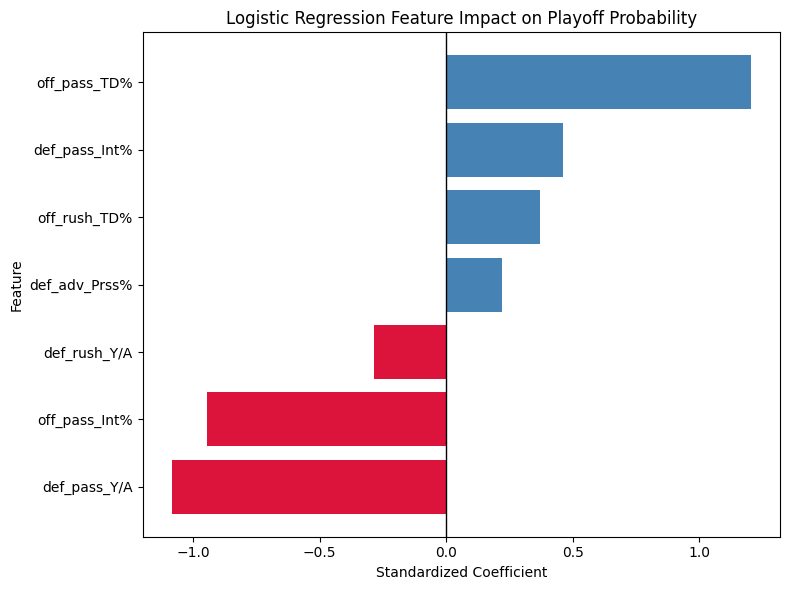

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale (important for interpretable coefficients)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit model
log_model = LogisticRegression()
log_model.fit(X_scaled, y)

# Build coefficient dataframe
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient")

# Plot
plt.figure(figsize=(8,6))
colors = ["crimson" if x < 0 else "steelblue" for x in coef_df["Coefficient"]]

plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)

plt.title("Logistic Regression Feature Impact on Playoff Probability")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## KFolds Confusion Matrix

In [18]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 5-fold CV
kf = KFold(n_splits=5, shuffle=False)

fold_accuracies = []
all_y_true = []
all_y_pred = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # scale within fold
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # logistic model
    log_model = LogisticRegression(max_iter=1000)
    log_model.fit(X_train_scaled, y_train)

    # predict
    y_pred = log_model.predict(X_test_scaled)

    # store fold accuracy
    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)

    # store for overall confusion matrix / report
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

# results
print("Logistic Fold Accuracies:", fold_accuracies)
print("Logistic Average Accuracy:", round(np.mean(fold_accuracies), 3))
print("Logistic Std Dev:", round(np.std(fold_accuracies), 3))

print("\nLogistic Confusion Matrix:")
print(confusion_matrix(all_y_true, all_y_pred))

print("\nLogistic Classification Report:")
print(classification_report(all_y_true, all_y_pred))

Logistic Fold Accuracies: [0.8653846153846154, 0.8823529411764706, 0.7058823529411765, 0.803921568627451, 0.8627450980392157]
Logistic Average Accuracy: 0.824
Logistic Std Dev: 0.065

Logistic Confusion Matrix:
[[128  20]
 [ 25  83]]

Logistic Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       148
           1       0.81      0.77      0.79       108

    accuracy                           0.82       256
   macro avg       0.82      0.82      0.82       256
weighted avg       0.82      0.82      0.82       256



## Introduce Rolling features (3 year averages) to predict next years playoff

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# load your model-ready dataset
df = pd.read_csv("team_stats_model_ready.csv")


# sort by team and season
df = df.sort_values(["team", "season"]).reset_index(drop=True)

# create 3-year rolling averages using prior 3 seasons only
for col in final_features:
    df[f"{col}_roll3"] = (
        df.groupby("team")[col]
        .transform(lambda s: s.shift(1).rolling(window=3, min_periods=3).mean())
    )

# this means:
# season 2021 row = avg of 2018, 2019, 2020
# season 2022 row = avg of 2019, 2020, 2021
# etc.

roll_cols = [f"{col}_roll3" for col in final_features]

# keep only rows where rolling features exist
df_roll = df.dropna(subset=roll_cols).copy()


#### Preview averages
print("Available seasons after rolling setup:")
print(sorted(df_roll["season"].unique()))
print(df_roll[["season", "team"] + roll_cols[:2]].head())

Available seasons after rolling setup:
[np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
   season               team  off_pass_TD%_roll3  off_pass_Int%_roll3
3    2021  Arizona Cardinals            3.766667             2.700000
4    2022  Arizona Cardinals            4.300000             2.133333
5    2023  Arizona Cardinals            3.966667             2.266667
6    2024  Arizona Cardinals            3.466667             2.233333
7    2025  Arizona Cardinals            3.233333             2.266667


Run Model, check accuracy

In [22]:
results = []
predictions = []

eval_years = [2021, 2022, 2023, 2024, 2025]

for test_year in eval_years:
    train_df = df_roll[df_roll["season"] < test_year].copy()
    test_df = df_roll[df_roll["season"] == test_year].copy()

    if train_df.empty or test_df.empty:
        continue

    X_train = train_df[roll_cols]
    y_train = train_df["made_playoffs"]

    X_test = test_df[roll_cols]
    y_test = test_df["made_playoffs"]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)

    probs = model.predict_proba(X_test_scaled)[:, 1]

    # Build prediction dataframe
    temp = test_df[["team", "season"]].copy()
    temp["playoff_probability"] = probs
    temp["actual"] = y_test.values

    # Rank + assign top 14
    temp = temp.sort_values("playoff_probability", ascending=False)
    temp["predicted_playoff_top14"] = 0
    temp.iloc[:14, temp.columns.get_loc("predicted_playoff_top14")] = 1

    acc = accuracy_score(temp["actual"], temp["predicted_playoff_top14"])

    results.append({
        "test_year": test_year,
        "accuracy": acc
    })

    predictions.append(temp)

results_df = pd.DataFrame(results)
predictions_df = pd.concat(predictions, ignore_index=True)

print(results_df)
print("\nAverage Accuracy:", round(results_df["accuracy"].mean(), 3))
print("Std Dev:", round(results_df["accuracy"].std(), 3))

   test_year  accuracy
0       2022    0.5625
1       2023    0.6250
2       2024    0.6250
3       2025    0.4375

Average Accuracy: 0.562
Std Dev: 0.088


Wanted to Compare last year 2025 to predicted and actual

In [23]:
pred_2025 = predictions_df[predictions_df["season"] == 2025].copy()

# Sort by probability
pred_2025 = pred_2025.sort_values("playoff_probability", ascending=False)

# Create prediction column
pred_2025["predicted_playoff_top14"] = 0
pred_2025.iloc[:14, pred_2025.columns.get_loc("predicted_playoff_top14")] = 1

# View results
print(pred_2025.head(14))


                      team  season  playoff_probability  actual  \
96           Detroit Lions    2025             0.716131       0   
97      Kansas City Chiefs    2025             0.655146       0   
98          Dallas Cowboys    2025             0.604671       0   
99       Green Bay Packers    2025             0.563525       1   
100     Cincinnati Bengals    2025             0.546462       0   
101          Buffalo Bills    2025             0.535441       1   
102       Seattle Seahawks    2025             0.473814       1   
103   Tampa Bay Buccaneers    2025             0.462271       0   
104         Miami Dolphins    2025             0.395698       0   
105    Philadelphia Eagles    2025             0.388887       1   
106      Minnesota Vikings    2025             0.388864       0   
107        New York Giants    2025             0.387886       0   
108         Denver Broncos    2025             0.386964       1   
109  Washington Commanders    2025             0.376306       

In [24]:
results_df[results_df["test_year"] == 2025]

,test_year,accuracy
3,2025,0.4375


## Predict 2026

In [25]:
# build 2026 prediction inputs directly from 2023-2025 averages
latest_years = [2023, 2024, 2025]

pred_2026_features = (
    df[df["season"].isin(latest_years)]
    .groupby("team")[final_features]
    .mean()
    .reset_index()
)

X_2026 = pred_2026_features[final_features].copy()

# train on all evaluable historical rolled rows
train_df = df_roll.copy()
X_train = train_df[roll_cols]
y_train = train_df["made_playoffs"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# align 2026 columns to training feature names
X_2026.columns = roll_cols
X_2026_scaled = scaler.transform(X_2026)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

pred_2026 = pred_2026_features[["team"]].copy()
pred_2026["playoff_probability"] = model.predict_proba(X_2026_scaled)[:, 1]

# sort by probability
pred_2026 = pred_2026.sort_values("playoff_probability", ascending=False).reset_index(drop=True)

# assign top 14 as playoff teams
pred_2026["predicted_playoff_top14"] = 0
pred_2026.iloc[:14, pred_2026.columns.get_loc("predicted_playoff_top14")] = 1

print(pred_2026.head(20))

                    team  playoff_probability  predicted_playoff_top14
0          Buffalo Bills             0.685847                        1
1          Detroit Lions             0.619676                        1
2         Dallas Cowboys             0.612548                        1
3     Cincinnati Bengals             0.594275                        1
4          Chicago Bears             0.541328                        1
5       Los Angeles Rams             0.535740                        1
6       Baltimore Ravens             0.528279                        1
7         Denver Broncos             0.516880                        1
8      Green Bay Packers             0.504281                        1
9   Los Angeles Chargers             0.499884                        1
10   Philadelphia Eagles             0.470134                        1
11   Pittsburgh Steelers             0.465637                        1
12        Houston Texans             0.442180                        1
13    

## Prediction Results

teams predicted to make playoffs next year

In [26]:
pred_2026.head(14)

,team,playoff_probability,predicted_playoff_top14
0,Buffalo Bills,0.685847,1
1,Detroit Lions,0.619676,1
2,Dallas Cowboys,0.612548,1
3,Cincinnati Bengals,0.594275,1
4,Chicago Bears,0.541328,1
5,Los Angeles Rams,0.535740,1
6,Baltimore Ravens,0.528279,1
7,Denver Broncos,0.516880,1
8,Green Bay Packers,0.504281,1
9,Los Angeles Chargers,0.499884,1
